# Linear readouts

In this notebook, linear readouts are performed across the NeuroFlow pipeline in a person/no person task. Images have previously classified to contain people vs no people. 310 high confidence samples have been selected for each category.

In [1]:
import torch
from sklearn.model_selection import KFold
import numpy as np
from sklearn.metrics import roc_auc_score

# On CLIP cls embeddings (sanity check)
If is does not work on the CLIP cls tokens, it cannot be expected to work on any other layer.

In [2]:
cls_embeddings_0 = torch.load("/u/fdammeier/artifacts/310other/cls_embeddings.pt")
cls_embeddings_1 = torch.load("/u/fdammeier/artifacts/310person/cls_embeddings.pt")

In [3]:
target_0 = torch.zeros(cls_embeddings_0.size(0))
target_1 = torch.ones(cls_embeddings_1.size(0))

targets = torch.cat([target_0, target_1])
cls_embeddings = torch.cat([cls_embeddings_0, cls_embeddings_1])
cls_embeddings = cls_embeddings.float()

In [4]:
class LinearReadout(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, 1)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

def build_model(kind, x):
    if kind == "linear":
        return LinearReadout(x.shape[1])
    return LinearReadoutTokens(x.shape[1], x.shape[2])

def kfold(x, y, kind, n_splits, lr, epochs, seed, device, tag):
    accs, aucs = [], []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (tr, va) in enumerate(kf.split(np.arange(len(x)))):
        torch.manual_seed(seed + fold)
        model = build_model(kind, x).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        crit = torch.nn.BCELoss()
        x_tr, y_tr = x[tr].to(device), y[tr].to(device)
        x_va, y_va = x[va].to(device), y[va]

        for epoch in range(epochs):  # full batch
            opt.zero_grad()
            loss = crit(model(x_tr).squeeze(-1), y_tr)
            loss.backward()
            opt.step()
            if (epoch + 1) % 10 == 0 or epoch + 1 == epochs:
                print(f"[{tag}] fold {fold + 1} epoch {epoch + 1}/{epochs} loss {loss.item():.4f}")

        model.eval()
        with torch.no_grad():
            probs = model(x_va).squeeze(-1).cpu()
        acc = ((probs > 0.5).float() == y_va).float().mean().item()
        auc = roc_auc_score(y_va.numpy(), probs.numpy())
        accs.append(acc)
        aucs.append(auc)
        print(f"[{tag}] fold {fold + 1} acc {acc:.4f} auc {auc:.4f}")

    print(f"[{tag}] mean acc {np.mean(accs):.4f} +- {np.std(accs):.4f}, "
          f"mean auc {np.mean(aucs):.4f} +- {np.std(aucs):.4f}")
    return accs, aucs

# _ = kfold(cls_embeddings, targets, "linear", n_splits=10, lr=1e-3, epochs=200, seed=42, device=torch.device("cpu"), tag="target")

# Image token embeddings

This is still CLIP and should contain most information. It is extremely high dimensional though, a conv layer will be used to created a single vector before the linear layer.

--> see linear_readouts.py

# fMRI reconstructions

In [41]:
fmri_recon_0 = torch.load("/u/fdammeier/artifacts/310other/reconstructed_fmri.pt")
fmri_recon_1 = torch.load("/u/fdammeier/artifacts/310person/reconstructed_fmri.pt")
fmri_recon = torch.cat([fmri_recon_0, fmri_recon_1], dim=0)

In [53]:
# we known that it works so, we simply train the model on the entire dataset
# to obtain weights that can be examined
class LinearReadout(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

x_tr = fmri_recon.to(torch.device("cpu")).flatten(start_dim=1)
y_tr = targets.to(torch.device("cpu"))

# standardize the input features
mean, std = x_tr.mean(dim=0), x_tr.std(dim=0)
x_st = (x_tr - mean) / std

input_dim = x_tr.shape[1]
model = LinearReadout(input_dim)          # outputs logits
crit = torch.nn.BCEWithLogitsLoss()
opt = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=500,
                        tolerance_grad=1e-7, tolerance_change=1e-12,
                        line_search_fn="strong_wolfe")

def closure():
    opt.zero_grad()
    loss = crit(model(x_st).squeeze(-1), y_tr.float())
    loss.backward()
    return loss

opt.step(closure)   # runs up to max_iter internally

tensor(0.7899, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [54]:
# get weights
weights = model.linear.weight.data
bias = model.linear.bias.data
weights = weights.flatten()
weights.shape, bias.shape

(torch.Size([15724]), torch.Size([1]))

In [55]:
# very basic mean calculation on ROIS
ROIS = ["bodies", "faces", "places", "v1", "v2", "v3", "v4"]
masks = [torch.load(f"/u/fdammeier/repositories/NeuroFlow/sample_data/integrated_gradients/2d_masks/subject_1/mask_{roi}.pt") for roi in ROIS]

def calc_roi_means(weights):
    for roi, roi_mask in zip(ROIS, masks):
        roi_mean = (weights * roi_mask.flatten()).mean()
        roi_std = (weights * roi_mask.flatten()).std()
        roi_sum = (weights * roi_mask.flatten()).sum()
        print(f"ROI {roi} weight (on {roi_mask.sum().item()} elements): sum : {roi_sum.item():.4f} mean: {roi_mean.item():.4f} std: {roi_std.item():.4f}")

    # combined mask
    combined_mask = torch.stack(masks).sum(dim=0).clamp(max=1)
    combined_mean = (weights * combined_mask.flatten()).mean()
    combined_std = (weights * combined_mask.flatten()).std()
    combined_sum = (weights * combined_mask.flatten()).sum()
    print(f"Combined mask weight (on {combined_mask.sum().item()} elements): sum : {combined_sum.item():.4f} mean: {combined_mean.item():.4f} std: {combined_std.item():.4f}")
    out_roi_mask = 1 - combined_mask
    out_roi_mean = (weights * out_roi_mask.flatten()).mean()
    out_roi_std = (weights * out_roi_mask.flatten()).std()
    out_roi_sum = (weights * out_roi_mask.flatten()).sum()
    print(f"Out-ROI mask weight (on {out_roi_mask.sum().item()} elements): sum : {out_roi_sum.item():.4f} mean: {out_roi_mean.item():.4f} std: {out_roi_std.item():.4f}")

calc_roi_means(weights)

ROI bodies weight (on 2934 elements): sum : 15.5621 mean: 0.0010 std: 0.0089
ROI faces weight (on 1042 elements): sum : 1.1255 mean: 0.0001 std: 0.0055
ROI places weight (on 2252 elements): sum : 3.5641 mean: 0.0002 std: 0.0069
ROI v1 weight (on 1350 elements): sum : 2.7120 mean: 0.0002 std: 0.0051
ROI v2 weight (on 1433 elements): sum : -1.8592 mean: -0.0001 std: 0.0058
ROI v3 weight (on 1187 elements): sum : -0.9084 mean: -0.0001 std: 0.0049
ROI v4 weight (on 687 elements): sum : -1.5202 mean: -0.0001 std: 0.0037
Combined mask weight (on 10100 elements): sum : 15.1497 mean: 0.0010 std: 0.0153
Out-ROI mask weight (on 5624 elements): sum : -8.0616 mean: -0.0005 std: 0.0129


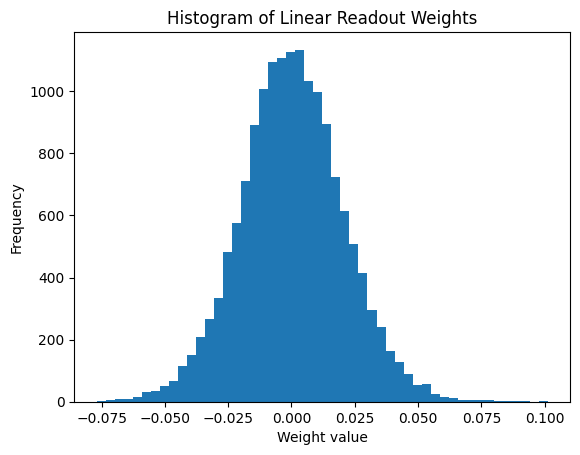

In [45]:
# calculate a histogram on the weights
import matplotlib.pyplot as plt

plt.hist(weights.numpy(), bins=50)
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.title("Histogram of Linear Readout Weights")
plt.show()

Very few voxels carry significant classification weight for the "person" category.

In [46]:
# calculate number of top 1% weights per ROI
top_1_percent_threshold = torch.quantile(weights, 0.99)

in_roi = 0
for roi in ROIS:
    roi_mask = torch.load(f"/u/fdammeier/repositories/NeuroFlow/sample_data/integrated_gradients/2d_masks/subject_1/mask_{roi}.pt")
    roi_weights = weights * roi_mask.flatten()
    top_1_count = (roi_weights > top_1_percent_threshold).sum()
    in_roi += top_1_count.item()
    print(f"ROI {roi} top 1% weight count: {top_1_count.item()}")
print(f"Total top 1% weights in all ROIs: {in_roi}")
print(f"Total top 1% weights not in any ROI: {(weights > top_1_percent_threshold).sum().item() - in_roi}")

ROI bodies top 1% weight count: 27
ROI faces top 1% weight count: 14
ROI places top 1% weight count: 26
ROI v1 top 1% weight count: 5
ROI v2 top 1% weight count: 11
ROI v3 top 1% weight count: 2
ROI v4 top 1% weight count: 0
Total top 1% weights in all ROIs: 85
Total top 1% weights not in any ROI: 73


In [56]:
# calculate number of positive weights per ROI
def calc_positive_weights_per_roi(weights):
    total_positive = (weights > 0).sum().item()

    in_roi = 0
    for roi, roi_mask in zip(ROIS, masks):
        roi_weights = weights * roi_mask.flatten()
        positive_count = (roi_weights > 0).sum()
        in_roi += positive_count.item()
        print(f"ROI {roi} positive weight count: {positive_count.item()}/{roi_mask.sum().item()} ({positive_count.item() / total_positive * 100:.2f}%)")
    print(f"Total positive weights in all ROIs: {in_roi} ({in_roi / total_positive * 100:.2f}%)")
    print(f"Total positive weights not in any ROI: {total_positive - in_roi} ({(total_positive - in_roi) / total_positive * 100:.2f}%)")

calc_positive_weights_per_roi(weights)

ROI bodies positive weight count: 1854/2934 (23.34%)
ROI faces positive weight count: 539/1042 (6.79%)
ROI places positive weight count: 1133/2252 (14.27%)
ROI v1 positive weight count: 760/1350 (9.57%)
ROI v2 positive weight count: 684/1433 (8.61%)
ROI v3 positive weight count: 577/1187 (7.27%)
ROI v4 positive weight count: 303/687 (3.82%)
Total positive weights in all ROIs: 5850 (73.66%)
Total positive weights not in any ROI: 2092 (26.34%)


In [57]:
# Extend to multiple models to check for robustness of results

kf = KFold(n_splits=10, shuffle=True, random_state=42)

val_accs = []
val_aucs = []
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(x_tr.shape[0]))):
    
    x_tr_fold = x_tr[train_idx]
    y_tr_fold = y_tr[train_idx]
    x_val_fold = x_tr[val_idx]
    y_val_fold = y_tr[val_idx]

    # standardize the input features
    mean, std = x_tr_fold.mean(dim=0), x_tr_fold.std(dim=0)
    x_tr_fold_st = (x_tr_fold - mean) / std
    x_val_fold_st = (x_val_fold - mean) / std

    input_dim = x_tr_fold.shape[1]
    model = LinearReadout(input_dim)          # outputs logits
    crit = torch.nn.BCEWithLogitsLoss()
    opt = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=500,
                            tolerance_grad=1e-7, tolerance_change=1e-12,
                            line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        loss = crit(model(x_tr_fold_st).squeeze(-1), y_tr_fold.float())
        loss.backward()
        return loss

    opt.step(closure)   # runs up to max_iter internally

    # evaluate on the validation fold
    with torch.no_grad():
        val_logits = model(x_val_fold_st).squeeze(-1)
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs > 0.5).float()
        val_acc = (val_preds == y_val_fold).float().mean().item()
        val_auc = roc_auc_score(y_val_fold.cpu().numpy(), val_probs.cpu().numpy())
        val_accs.append(val_acc)
        val_aucs.append(val_auc)
    models.append(model)

In [58]:
print(val_accs)
print(val_aucs)

[0.9677419066429138, 0.9677419066429138, 0.9193548560142517, 0.9838709831237793, 0.9838709831237793, 1.0, 0.9838709831237793, 0.9677419066429138, 0.9677419066429138, 0.9516128897666931]
[0.996875, 0.9989594172736733, 0.9860627177700348, 0.9958333333333333, 1.0, 1.0, 1.0, 0.9647435897435898, 0.9989583333333334, 0.9937304075235109]


In [61]:
weights = torch.stack([model.linear.weight.squeeze(0) for model in models])
print(weights.shape)

torch.Size([10, 15724])


In [60]:
# are the models robust?
calc_roi_means(weights.mean(dim=0))

ROI bodies weight (on 2934 elements): sum : 16.2952 mean: 0.0010 std: 0.0084
ROI faces weight (on 1042 elements): sum : 1.2644 mean: 0.0001 std: 0.0051
ROI places weight (on 2252 elements): sum : 3.0941 mean: 0.0002 std: 0.0063
ROI v1 weight (on 1350 elements): sum : 2.5988 mean: 0.0002 std: 0.0045
ROI v2 weight (on 1433 elements): sum : -1.9510 mean: -0.0001 std: 0.0052
ROI v3 weight (on 1187 elements): sum : -0.5670 mean: -0.0000 std: 0.0044
ROI v4 weight (on 687 elements): sum : -1.3787 mean: -0.0001 std: 0.0034
Combined mask weight (on 10100 elements): sum : 15.8366 mean: 0.0010 std: 0.0140
Out-ROI mask weight (on 5624 elements): sum : -8.8658 mean: -0.0006 std: 0.0120


In [62]:
calc_positive_weights_per_roi(weights.mean(dim=0))

ROI bodies positive weight count: 1904/2934 (23.93%)
ROI faces positive weight count: 540/1042 (6.79%)
ROI places positive weight count: 1130/2252 (14.20%)
ROI v1 positive weight count: 748/1350 (9.40%)
ROI v2 positive weight count: 677/1433 (8.51%)
ROI v3 positive weight count: 582/1187 (7.32%)
ROI v4 positive weight count: 297/687 (3.73%)
Total positive weights in all ROIs: 5878 (73.89%)
Total positive weights not in any ROI: 2077 (26.11%)


In [66]:
# Does removing the "bodies" ROI affect model performance?
bodies_mask = masks[0]
x_tr_no_bodies = x_tr[:, bodies_mask.flatten() == 0]

kf = KFold(n_splits=10, shuffle=True, random_state=42)

val_accs = []
val_aucs = []
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(x_tr.shape[0]))):
    
    x_tr_fold = x_tr_no_bodies[train_idx]
    y_tr_fold = y_tr[train_idx]
    x_val_fold = x_tr_no_bodies[val_idx]
    y_val_fold = y_tr[val_idx]

    # standardize the input features
    mean, std = x_tr_fold.mean(dim=0), x_tr_fold.std(dim=0)
    x_tr_fold_st = (x_tr_fold - mean) / std
    x_val_fold_st = (x_val_fold - mean) / std

    input_dim = x_tr_fold.shape[1]
    model = LinearReadout(input_dim)          # outputs logits
    crit = torch.nn.BCEWithLogitsLoss()
    opt = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=500,
                            tolerance_grad=1e-7, tolerance_change=1e-12,
                            line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        loss = crit(model(x_tr_fold_st).squeeze(-1), y_tr_fold.float())
        loss.backward()
        return loss

    opt.step(closure)   # runs up to max_iter internally

    # evaluate on the validation fold
    with torch.no_grad():
        val_logits = model(x_val_fold_st).squeeze(-1)
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs > 0.5).float()
        val_acc = (val_preds == y_val_fold).float().mean().item()
        val_auc = roc_auc_score(y_val_fold.cpu().numpy(), val_probs.cpu().numpy())
        val_accs.append(val_acc)
        val_aucs.append(val_auc)
    models.append(model)

print(f"Mean validation accuracy: {np.mean(val_accs):.4f}")
print(f"Mean validation AUC: {np.mean(val_aucs):.4f}")

Mean validation accuracy: 0.9694
Mean validation AUC: 0.9926


No.

In [68]:
# Can the "bodies" region alone predict the target?
bodies_mask = masks[0]
x_tr_bodies = x_tr[:, bodies_mask.flatten() == 1]
print(x_tr_bodies.shape)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

val_accs = []
val_aucs = []
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(x_tr.shape[0]))):
    
    x_tr_fold = x_tr_bodies[train_idx]
    y_tr_fold = y_tr[train_idx]
    x_val_fold = x_tr_bodies[val_idx]
    y_val_fold = y_tr[val_idx]

    # standardize the input features
    mean, std = x_tr_fold.mean(dim=0), x_tr_fold.std(dim=0)
    x_tr_fold_st = (x_tr_fold - mean) / std
    x_val_fold_st = (x_val_fold - mean) / std

    input_dim = x_tr_fold.shape[1]
    model = LinearReadout(input_dim)          # outputs logits
    crit = torch.nn.BCEWithLogitsLoss()
    opt = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=500,
                            tolerance_grad=1e-7, tolerance_change=1e-12,
                            line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        loss = crit(model(x_tr_fold_st).squeeze(-1), y_tr_fold.float())
        loss.backward()
        return loss

    opt.step(closure)   # runs up to max_iter internally

    # evaluate on the validation fold
    with torch.no_grad():
        val_logits = model(x_val_fold_st).squeeze(-1)
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs > 0.5).float()
        val_acc = (val_preds == y_val_fold).float().mean().item()
        val_auc = roc_auc_score(y_val_fold.cpu().numpy(), val_probs.cpu().numpy())
        val_accs.append(val_acc)
        val_aucs.append(val_auc)
    models.append(model)

print(f"Mean validation accuracy: {np.mean(val_accs):.4f}")
print(f"Mean validation AUC: {np.mean(val_aucs):.4f}")

torch.Size([620, 2934])
Mean validation accuracy: 0.9629
Mean validation AUC: 0.9925


Yes.